# Audience Segmentation for a Live-Events Organization — Statistical Analysis

**Capstone project · Post-Graduate Diploma in AI & Data Science, Loyalist College (2024) · Grade: 97%**

## Business question
The client's marketing department ran events at two venues: a large **Arena** and a smaller **Music-and-Bar** venue. They suspected the two audiences were different markets. **Should each venue be marketed as a separate segment?**

## Data
- A guest survey (43 questions) sent to **7,582** ticket buyers, with **1,424** responses.
- Joined to **ticketing-platform** records using the customer email as the key, so each answer is linked to the venue attended. **674** respondents matched one of the two venues.
- Emails were hashed before analysis (see the last cell).
- **The data isn't included in this repository**, because the client is under a non-disclosure agreement and all client names have been replaced. To re-run the notebook, place the combined file at `data/combined_data.xlsx`.

## Methods
Welch's t-test · chi-square test of independence · linear regression · probability-density / frequency analysis
(Python: pandas, NumPy, SciPy, matplotlib, seaborn)

## Key findings
| Question | Result | Significant? |
|---|---|---|
| Do the venues differ in **age**? | Music-and-Bar guests are older (mean 59.4 vs 51.6)* | **Yes** (p ≈ 7×10⁻¹⁶)* |
| Do they differ in **preferred day/time**? | Music-and-Bar guests are ~2.4× more likely to prefer **weekday daytime** (14.3% vs 5.9%); Arena guests lean toward **weekend evenings** (37.1% vs 26.3%) | **Yes** (χ² = 54.3, df = 7, p ≈ 2×10⁻⁹) |
| Do they differ in **household income**? | Very similar means ($107.8k vs $108.2k)* | No (p = 0.91)* |
| Do they differ in **spending per night out**? | Similar means ($178 vs $189)* | No (p = 0.26)* |
| Does income predict spending? | Yes at both venues, but weakly (R² 0.12–0.15)* | Yes (p < 10⁻⁸)* |

\* *From the original 2024 run, which counted "prefer not to say" as a midpoint value. This version drops those answers instead, so these numbers can change slightly when the notebook is re-run on the confidential data. The chi-square result doesn't depend on that change.*

**Recommendation:** the two audiences share an economic profile, so pricing and offers can be shared. But they differ in **age** and **when they want to attend**. Music-and-Bar programming and promotion should target older guests and weekday daytime slots, and Arena promotion should concentrate on weekend evenings.

> **Revision note (2026):** the original submitted report read the chi-square result the wrong way round ("no difference in preferred day"). A large χ² with p ≈ 2×10⁻⁹ *rejects* independence, so preferred day **does** depend on venue. This version fixes that and several code issues. See *Changes from the original submission* at the end.

## Setup
Shared imports, the data path, and the mappings from answer ranges to numbers, defined once and used by every test.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, chi2_contingency, norm

# Path to the combined survey + ticketing data (not included, client under NDA)
DATA_PATH = Path("data") / "combined_data.xlsx"

VENUE_COL = "Event Name"
MUSIC_AND_BAR = "Music and Bar"
ARENA = "Arena"

AGE_COL = "Age range"
INCOME_COL = "Annual household income"
SPENDING_COL = "Spending habits per evening out"

# Survey answers are ranges. Each range is replaced by its midpoint.
# "Prefer not to say" / "Not applicable" are treated as missing (NaN) and dropped,
# so they don't pull every group toward the same made-up value.
age_range_mapping = {
    "19-24": 21.5,
    "25-34": 29.5,
    "35-44": 39.5,
    "45-54": 49.5,
    "55-64": 59.5,
    "65+": 69.5,              # open-ended top range: 65 + half a 10-year band
    "Prefer not to say": np.nan,
}

income_range_mapping = {
    "Less than $25,000": 12500,
    "$25,000–$49,999": 37499.5,
    "$50,000–$74,999": 62499.5,
    "$75,000–$99,999": 87499.5,
    "$100,000–$124,999": 112499.5,
    "$125,000–$149,999": 137499.5,
    "$150,000+": 162499.5,    # open-ended top range: 150,000 + half a band
    "Prefer not to say": np.nan,
}

spending_range_mapping = {
    "$0 to $50": 25.5,
    "$51 to $100": 75.5,
    "$101 to $200": 150.5,
    "$201 to $300": 250.5,
    "$301 to $500": 400.5,
    "More than $500": 600,
    "Not applicable": np.nan,
}


def load_data():
    """Load the combined data and convert the range answers to numbers."""
    df = pd.read_excel(DATA_PATH)
    df[AGE_COL] = df[AGE_COL].map(age_range_mapping)
    df[INCOME_COL] = df[INCOME_COL].map(income_range_mapping)
    df[SPENDING_COL] = df[SPENDING_COL].map(spending_range_mapping)
    return df


def split_by_venue(df):
    return df[df[VENUE_COL] == MUSIC_AND_BAR], df[df[VENUE_COL] == ARENA]


df = load_data()
music_and_bar_data, arena_data = split_by_venue(df)
print("Music and Bar rows:", len(music_and_bar_data))
print("Arena rows:", len(arena_data))

## 1. Welch's t-test — do the venues differ in age, income and spending? (report pages 3–5)
Welch's version of the t-test is used for all three variables because it doesn't assume the two groups have equal variances. Their standard deviations do differ.

In [ ]:
def welch_t_test(column, label):
    """Run Welch's t-test on one column and plot both distributions with fitted normal curves."""
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
    music_and_bar_values = music_and_bar_data[column].dropna()
    arena_values = arena_data[column].dropna()

    t_statistic, p_value = stats.ttest_ind(music_and_bar_values, arena_values, equal_var=False)

    print(f"===== {label} =====")
    print("Music and Bar Mean:", music_and_bar_values.mean())
    print("Arena Mean:", arena_values.mean())
    print("Music and Bar Standard Deviation:", music_and_bar_values.std())
    print("Arena Standard Deviation:", arena_values.std())
    print("Music and Bar Sample Size (n):", len(music_and_bar_values))
    print("Arena Sample Size (n):", len(arena_values))
    print("Missing / not disclosed:", df[column].isna().sum())
    print("T-statistic:", t_statistic)
    print("P-value:", p_value)
    print("Significant at alpha = 0.05:", p_value < 0.05)

    # Plot
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlim.html
    plt.figure(figsize=(10, 6))
    plt.hist(music_and_bar_values, alpha=0.5, label=MUSIC_AND_BAR, density=True)
    plt.hist(arena_values, alpha=0.5, label=ARENA, density=True)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    plt.plot(x, norm.pdf(x, music_and_bar_values.mean(), music_and_bar_values.std()),
             "k", linewidth=2, linestyle="--", label=f"{MUSIC_AND_BAR} (Normal)")
    plt.plot(x, norm.pdf(x, arena_values.mean(), arena_values.std()),
             "k", linewidth=2, linestyle="-", label=f"{ARENA} (Normal)")
    plt.xlabel(label)
    plt.ylabel("Probability Density")
    plt.title(f"{label} distribution by venue")
    plt.legend()
    plt.show()


welch_t_test(AGE_COL, "Age")

In [ ]:
welch_t_test(INCOME_COL, "Annual household income")

In [ ]:
welch_t_test(SPENDING_COL, "Spending per evening out")

## 2. Chi-square test of independence — preferred day and time (report pages 6–8)
Survey question: *"Which days and times are you most interested in attending events?"* Answers are counted by venue.

**Null hypothesis (H₀):** preferred day/time is independent of venue.
If χ² is larger than the critical value (equivalently, if p < 0.05), H₀ is rejected. That would mean the two audiences **do** prefer different days.

*Note: this was a multi-select question, so one respondent can add to several cells. The test treats every answer as independent, so read the p-value as approximate. The difference is still very large.*

Answers - Arena: 1013  Music and Bar: 593  Total: 1606
Chi-squared statistic: 54.30941517922938
Degrees of freedom: 7
Critical chi-squared value (alpha=0.05): 14.067140449340169
p-value: 2.042676712083393e-09
Result: reject H0 -> preferred day/time DEPENDS on the venue.


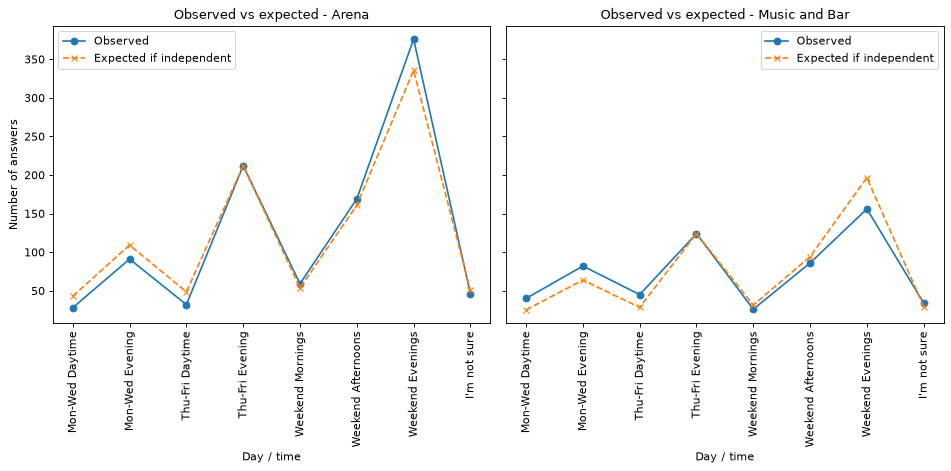

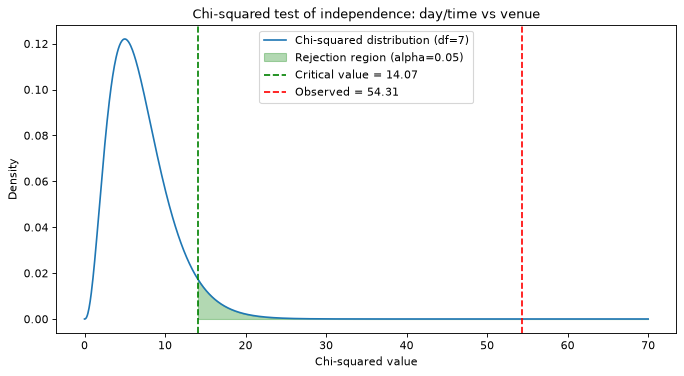

In [1]:
# Observed counts by venue (from the survey, summed per answer option)
days_of_week = ["Mon-Wed Daytime", "Mon-Wed Evening", "Thu-Fri Daytime", "Thu-Fri Evening",
                "Weekend Mornings", "Weekend Afternoons", "Weekend Evenings", "I'm not sure"]
arena_freq = np.array([28, 91, 32, 212, 59, 169, 376, 46])
music_bar_freq = np.array([40, 82, 45, 124, 26, 86, 156, 34])

# The contingency table: rows = day/time option, columns = venue
observed = np.column_stack([arena_freq, music_bar_freq])
print("Answers - Arena:", arena_freq.sum(), " Music and Bar:", music_bar_freq.sum(), " Total:", observed.sum())

# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html
chi2_statistic, p, dof, expected = chi2_contingency(observed)

alpha = 0.05
critical_chi2 = chi2.ppf(1 - alpha, dof)

print("Chi-squared statistic:", chi2_statistic)
print("Degrees of freedom:", dof)
print("Critical chi-squared value (alpha=0.05):", critical_chi2)
print("p-value:", p)
if chi2_statistic > critical_chi2:
    print("Result: reject H0 -> preferred day/time DEPENDS on the venue.")
else:
    print("Result: cannot reject H0 -> no evidence that preferred day/time depends on the venue.")

# Observed vs expected counts (expected = what we'd see if day and venue were independent)
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ax, obs, exp, title in [(axes[0], arena_freq, expected[:, 0], ARENA),
                            (axes[1], music_bar_freq, expected[:, 1], MUSIC_AND_BAR)]:
    ax.plot(days_of_week, obs, label="Observed", marker="o")
    ax.plot(days_of_week, exp, label="Expected if independent", linestyle="--", marker="x")
    ax.set_title(f"Observed vs expected - {title}")
    ax.set_xlabel("Day / time")
    ax.tick_params(axis="x", rotation=90)
    ax.legend()
axes[0].set_ylabel("Number of answers")
plt.tight_layout()
plt.show()

# The chi-squared distribution with the critical value and the observed statistic
x = np.linspace(0, max(70, chi2_statistic + 10), 1000)
plt.figure(figsize=(10, 5))
plt.plot(x, chi2.pdf(x, dof), label=f"Chi-squared distribution (df={dof})")
plt.fill_between(x, 0, chi2.pdf(x, dof), where=(x >= critical_chi2), color="green", alpha=0.3,
                 label=f"Rejection region (alpha={alpha})")
plt.axvline(x=critical_chi2, color="g", linestyle="--", label=f"Critical value = {critical_chi2:.2f}")
plt.axvline(x=chi2_statistic, color="r", linestyle="--", label=f"Observed = {chi2_statistic:.2f}")
plt.xlabel("Chi-squared value")
plt.ylabel("Density")
plt.title("Chi-squared test of independence: day/time vs venue")
plt.legend()
plt.show()

### Which options drive the difference?
The chi-square test only says *that* the distributions differ. Comparing each venue's share of answers, and the standardized residuals, shows *where* they differ. A residual above +2 or below −2 is a notable deviation from independence.

                    Arena share  Music-and-Bar share  Arena residual  Music-and-Bar residual
Mon-Wed Daytime           0.028                0.067          -2.274                   2.972
Mon-Wed Evening           0.090                0.138          -1.735                   2.267
Thu-Fri Daytime           0.032                0.076          -2.377                   3.107
Thu-Fri Evening           0.209                0.209           0.004                  -0.006
Weekend Mornings          0.058                0.044           0.735                  -0.961
Weekend Afternoons        0.167                0.145           0.643                  -0.841
Weekend Evenings          0.371                0.263           2.207                  -2.885
I'm not sure              0.045                0.057          -0.628                   0.821

Weekday daytime share - Arena: 5.9%, Music and Bar: 14.3%


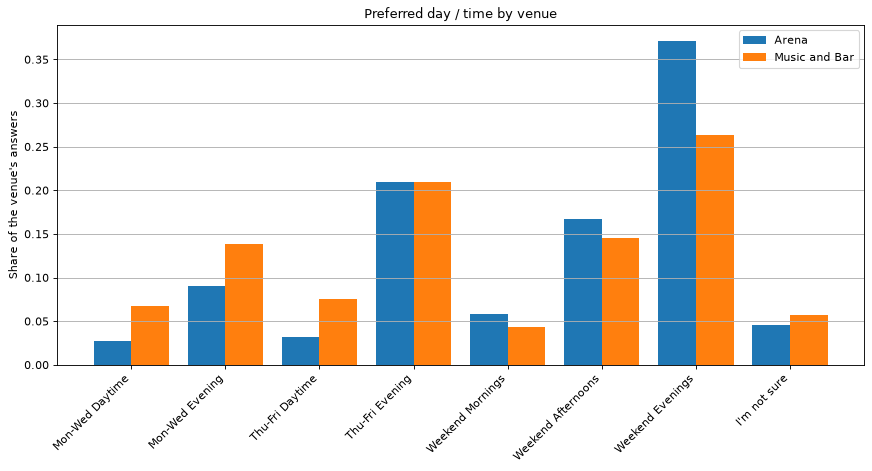

In [2]:
arena_share = arena_freq / arena_freq.sum()
music_bar_share = music_bar_freq / music_bar_freq.sum()
std_residuals = (observed - expected) / np.sqrt(expected)

summary = pd.DataFrame({
    "Arena share": arena_share,
    "Music-and-Bar share": music_bar_share,
    "Arena residual": std_residuals[:, 0],
    "Music-and-Bar residual": std_residuals[:, 1],
}, index=days_of_week)
print(summary.round(3).to_string())

weekday_daytime = [0, 2]
print(f"\nWeekday daytime share - Arena: {arena_share[weekday_daytime].sum():.1%}, "
      f"Music and Bar: {music_bar_share[weekday_daytime].sum():.1%}")

# Each venue's distribution is normalized by that venue's own total, so the bars are comparable
x_pos = np.arange(len(days_of_week))
width = 0.4
plt.figure(figsize=(11, 6))
plt.bar(x_pos - width / 2, arena_share, width, label=ARENA)
plt.bar(x_pos + width / 2, music_bar_share, width, label=MUSIC_AND_BAR)
plt.xticks(x_pos, days_of_week, rotation=45, ha="right")
plt.ylabel("Share of the venue's answers")
plt.title("Preferred day / time by venue")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 3. Linear regression (report pages 8–10)
Three simple regressions per venue: age → income, age → spending, and income → spending.
R² gives the share of variance explained, and the p-value tests whether the slope is different from zero.

In [ ]:
def regression_by_venue(x_col, y_col, x_label, y_label):
    """Fit a separate simple linear regression for each venue and plot both fits."""
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html
    plt.figure(figsize=(10, 6))
    print(f"===== {x_label} -> {y_label} =====")
    for venue_name, venue_df, color in [(MUSIC_AND_BAR, music_and_bar_data, "tab:blue"),
                                        (ARENA, arena_data, "tab:green")]:
        cleaned = venue_df.dropna(subset=[x_col, y_col])
        result = stats.linregress(cleaned[x_col], cleaned[y_col])
        print(f"{venue_name}:")
        print("  Slope:", result.slope)
        print("  Intercept:", result.intercept)
        print("  R-squared:", result.rvalue ** 2)
        print("  P-value:", result.pvalue)
        print("  Degrees of Freedom:", len(cleaned) - 2)
        print("  Number of data points used:", len(cleaned))

        plt.scatter(cleaned[x_col], cleaned[y_col], color=color, alpha=0.4, label=f"{venue_name} data points")
        x_line = np.linspace(cleaned[x_col].min(), cleaned[x_col].max(), 100)
        plt.plot(x_line, result.intercept + result.slope * x_line, color=color, linestyle="--",
                 label=f"{venue_name} fit (R²={result.rvalue ** 2:.3f})")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"Linear regression: {x_label} vs {y_label}")
    plt.legend()
    plt.grid(True)
    plt.show()


regression_by_venue(AGE_COL, INCOME_COL, "Age", "Annual household income")

In [ ]:
regression_by_venue(AGE_COL, SPENDING_COL, "Age", "Spending per evening out")

In [ ]:
regression_by_venue(INCOME_COL, SPENDING_COL, "Annual household income", "Spending per evening out")

## 4. Frequency analysis and averages (report pages 11–12)

In [ ]:
print("Overall averages (both venues):")
print("  Average Age:", df[AGE_COL].mean())
print("  Average Annual Household Income:", df[INCOME_COL].mean())
print("  Average Spending per Evening Out:", df[SPENDING_COL].mean())

for column, label in [(INCOME_COL, "Income"), (SPENDING_COL, "Spending per evening out")]:
    print(f"\n===== {label}: answer counts by venue =====")
    for venue_name, venue_df in [(MUSIC_AND_BAR, music_and_bar_data), (ARENA, arena_data)]:
        print(f"{venue_name} (n = {venue_df[column].notna().sum()} answered, "
              f"{venue_df[column].isna().sum()} not disclosed):")
        print(venue_df[column].value_counts().sort_index().to_string())
        print(f"Average: {venue_df[column].mean():.2f}\n")

In [ ]:
def density_by_venue(column, label):
    """Kernel density estimate of one variable per venue, with a fitted normal curve and the mean."""
    # https://seaborn.pydata.org/generated/seaborn.kdeplot.html
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (venue_name, venue_df) in zip(axes, [(MUSIC_AND_BAR, music_and_bar_data), (ARENA, arena_data)]):
        values = venue_df[column].dropna()
        sns.kdeplot(x=values, bw_adjust=0.5, fill=True, color="tab:blue", label="Density", ax=ax)
        x = np.linspace(values.min(), values.max(), 100)
        ax.plot(x, norm.pdf(x, values.mean(), values.std()), "r--", label="Normal distribution curve")
        ax.axvline(x=values.mean(), color="green", linestyle="--",
                   label=f"Mean = {values.mean():.2f}\nVariance = {values.var():.2f}")
        ax.set_title(f"{label} - {venue_name}")
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.legend()
    plt.tight_layout()
    plt.show()


density_by_venue(AGE_COL, "Age")
density_by_venue(INCOME_COL, "Annual household income")
density_by_venue(SPENDING_COL, "Spending per evening out")

## 5. Data preparation (run once, before the analysis)
These are the two steps used to build the combined file. They are shown for completeness and aren't run as part of the analysis.
1. Label each ticketing record with its venue.
2. Hash customer emails, so the survey and ticketing data can still be joined without exposing anyone's address.

In [ ]:
# Step 1 - label each ticketing record with its venue.
# Show names were replaced with placeholders to respect the client's non-disclosure agreement.
TICKETING_EXPORT = Path("data") / "ticketing_export.xlsx"
LABELED_EXPORT = Path("data") / "ticketing_export_labeled.xlsx"

music_and_bar_events = [f"Show {n}" for n in range(1, 11)]
arena_events = [f"Show {n}" for n in range(11, 21)]


def label_venues(ticketing_df):
    """Add a venue column: Music and Bar, Arena, or Other."""
    ticketing_df = ticketing_df.copy()
    ticketing_df["Venue"] = "Other"
    ticketing_df.loc[ticketing_df["Event Name"].isin(music_and_bar_events), "Venue"] = MUSIC_AND_BAR
    ticketing_df.loc[ticketing_df["Event Name"].isin(arena_events), "Venue"] = ARENA
    return ticketing_df


# ticketing = label_venues(pd.read_excel(TICKETING_EXPORT))
# ticketing.to_excel(LABELED_EXPORT, index=False)

In [ ]:
# Step 2 - hash the email addresses.
# A salted SHA-256 hash is used: the same email always gives the same value (so the join still works),
# but the addresses can't be recovered by hashing a list of known emails without the secret salt.
import hashlib
import os

SALT = os.environ.get("EMAIL_HASH_SALT", "")  # keep the real salt out of the code


def hash_email(email):
    if pd.isna(email):
        return email
    normalized = str(email).strip().lower()
    return hashlib.sha256((SALT + normalized).encode("utf-8")).hexdigest()


# raw = pd.read_excel(Path("data") / "combined_data_raw.xlsx")
# raw["Customer Email"] = raw["Customer Email"].apply(hash_email)
# raw.to_excel(DATA_PATH, index=False)  # write to a new file; never overwrite the raw data

## Conclusion
Of the four characteristics the marketing team chose, the audiences at the two venues **match on income and spending** but **differ on age and on preferred day/time**. A single brand message and price structure fits both. Scheduling and targeted promotion should differ: older guests and weekday daytime slots for the Music-and-Bar venue, and weekend evenings for the Arena.

**Limitations:** survey responses are self-selected (about 19% response rate); ranges were converted to midpoints; "prefer not to say" answers were excluded; and the day/time question was multi-select. The other 39 survey questions weren't analyzed and could refine the profiles further.

## Changes from the original submission
- **Chi-square interpretation fixed.** The original report concluded "no difference in preferred day", but χ² = 54.3 (df = 7, p ≈ 2×10⁻⁹) rejects independence. Added shares and standardized residuals to show where the difference is.
- **Removed an invalid test.** The original per-venue "chi-square" passed the expected counts to `chi2_contingency` as if they were a second row of observed data.
- **Corrected totals.** Music-and-Bar has 593 day/time answers and the grand total is 1,606 (the report said 539 and 1,567). Each venue's percentages now use that venue's own total, and the bar chart bars no longer overlap.
- **Consistent t-test.** Welch's t-test is now used for all three variables (the income test used the equal-variance version).
- **"Prefer not to say" is treated as missing.** It was previously filled in with a midpoint value (for ~25% of income answers), which pulls both groups toward the same value and hides real differences.
- **One mapping for each variable,** defined in the setup cell (the original had `$0–$50` as 25 in some cells and 25.5 in others).
- **Data-prep code fixed.** It referenced an undefined variable, used inconsistent column names and absolute local paths, and overwrote the source file. It also now uses a salted hash instead of unsalted MD5.
- **Repeated code** (loading, mapping, plotting) moved into small functions.

The outputs of sections 1, 3 and 4 are left empty because they need the confidential data file to re-run. The code was tested end to end on synthetic data with the same columns. The chi-square results in section 2 use counts that are written into the notebook, so they're shown here.